<a href="https://colab.research.google.com/github/asepmuhidin/citra/blob/main/format_citra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2

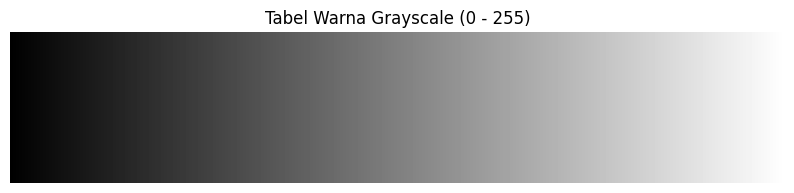

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ===== Membuat nilai grayscale 0-255 =====
gray_table = np.arange(256, dtype=np.uint8)

# Ubah jadi gambar 2D (tinggi 50 pixel)
gray_table = np.tile(gray_table, (50, 1))

# ===== Tampilkan =====
plt.figure(figsize=(10,2))
plt.imshow(gray_table, cmap='gray', vmin=0, vmax=255)
plt.title("Tabel Warna Grayscale (0 - 255)")
plt.axis("off")
plt.show()

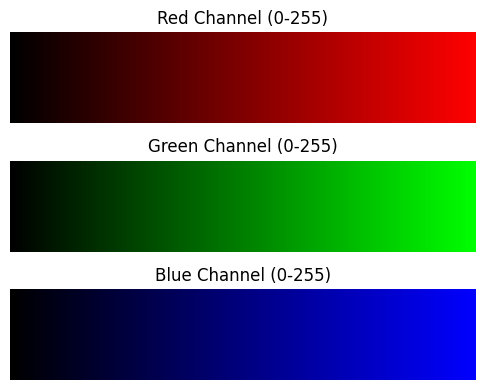

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ===== Membuat nilai 0-255 =====
values = np.arange(256, dtype=np.uint8)

# ===== Membuat tabel RGB =====
red = np.zeros((50, 256, 3), dtype=np.uint8)
green = np.zeros((50, 256, 3), dtype=np.uint8)
blue = np.zeros((50, 256, 3), dtype=np.uint8)

# Isi channel warna
red[:, :, 0] = values
green[:, :, 1] = values
blue[:, :, 2] = values

# ===== Tampilkan =====
plt.figure(figsize=(10,4))

plt.subplot(3,1,1)
plt.imshow(red)
plt.title("Red Channel (0-255)")
plt.axis("off")

plt.subplot(3,1,2)
plt.imshow(green)
plt.title("Green Channel (0-255)")
plt.axis("off")

plt.subplot(3,1,3)
plt.imshow(blue)
plt.title("Blue Channel (0-255)")
plt.axis("off")

plt.tight_layout()
plt.show()

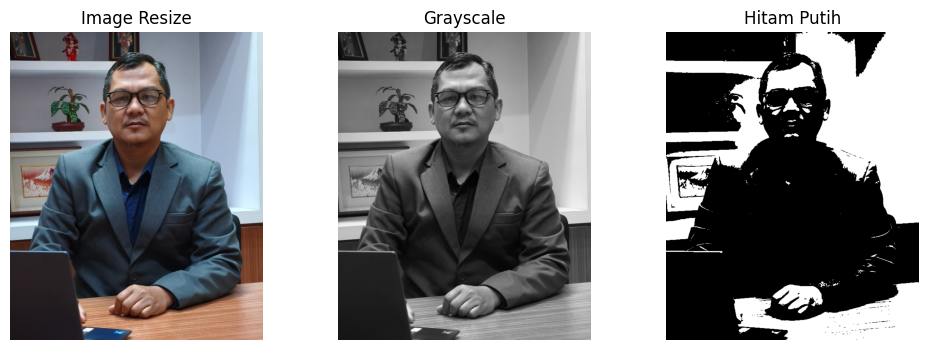

In [11]:
import urllib.request
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ===== 1. Load image dari URL =====
path = "https://raw.githubusercontent.com/asepmuhidin/citra/main/me.jpeg"

req = urllib.request.urlopen(path)
arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
img = cv2.imdecode(arr, cv2.IMREAD_COLOR)

# ===== 2. Resize (ubah proporsi) =====
scale_percent = 50
width = int(img.shape[1] * scale_percent / 100)
height = int(img.shape[0] * scale_percent / 100)

resized = cv2.resize(img, (width, height), interpolation=cv2.INTER_AREA)

# ===== 3. Grayscale =====
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

# ===== 4. Hitam Putih =====
_, bw = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# ===== 5. OpenCV BGR -> RGB (WAJIB untuk matplotlib) =====
img_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

# ===== 6. Tampilkan dengan matplotlib =====
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Image Resize")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(bw, cmap='gray')
plt.title("Hitam Putih")
plt.axis("off")

plt.show()